# Preproceso de los datos
**Author**: RoSaGo  
**Date**: May 2026

## Caso de Estudio

### Planteamiento del problema

La empresa XYZ cuenta con unos 4.000 empleados, pero cada año pierde aproximadamente el 15% de su plantilla. La dirección considera que esta tasa de rotación es perjudicial por tres motivos principales: retrasos en proyectos, necesidad de mantener un departamento de reclutamiento y costes de formación de nuevos empleados.

Por ello, han contratado una consultora de analítica de RRHH para identificar qué factores provocan la rotación y qué cambios organizativos ayudarían a retener el talento.

### Objetivo

En esta primera fase el objetivo es preparar y sanear el conjunto de datos antes de proceder al modelado. Para ello, se llevarán a cabo la carga y normalización de las variables —tanto cualitativas como cuantitativas—, la detección y tratamiento de valores atípicos, la imputación de datos faltantes y la creación de nuevas variables derivadas. Finalmente, se realizará un estudio descriptivo para validar el resultado del preprocesamiento y se exportará el dataset limpio, acompañado de un informe ejecutivo que documente todas las decisiones tomadas a lo largo del proceso.

### El conjunto de datos

El conjunto de datos recoge información detallada sobre los empleados de la empresa XYZ, combinando variables demográficas (edad, género, estado civil, nivel educativo), laborales (departamento, puesto, nivel jerárquico, años en la empresa, años con el manager actual) y económicas (salario mensual, incremento salarial, nivel de opciones sobre acciones).

Además, incluye indicadores subjetivos de bienestar y compromiso, como la satisfacción con el entorno de trabajo, con el puesto, con las relaciones interpersonales y el equilibrio entre vida personal y laboral, así como el nivel de implicación en el trabajo y la valoración del rendimiento. La variable objetivo es Attrition, que indica si el empleado abandonó la empresa el año anterior, lo que permite construir un modelo predictivo para identificar los factores que más influyen en la rotación de personal.

Fuente kaggle: [HR Analytics Case Study](https://www.kaggle.com/datasets/vjchoudhary7/hr-analytics-case-study/data)

## Índice

* 1 Carga de los archivo
* 2 Valores atípicos
* 3 Imputación de valores
* 4 Creación de nuevas variables
* 5 Estudio descriptivo
   * 5.1 Estudio descriptivo de las variables cualitativas
   * 5.2 Estudio descriptivo de las variables cuantitativas
* 6 Archivo final
* 7 Informe ejecutivo

In [37]:
%pip install numpy pandas seaborn matplotlib scikit-learn flake8 pycodestyle pycodestyle-magic
print("Done installing libraries.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Done installing libraries.


In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
seed = 100

%matplotlib inline

# 1 Carga de los archivo

Cargar los datasets para explorar su estructura básica (número de filas y nombre de los atributos), contrastar las variables con la documentación oficial del dataset, y verificar si existen valores faltantes.

## Descripción del conjunto de datos

* **general_data.csv**: El archivo contiene información general de los empleados, incluyendo datos demográficos (edad, género), laborales (departamento, nivel educativo y campo de estudios, frecuencia de viajes de negocio) y administrativos (ID del empleado, número de empleados). También recoge la variable objetivo Attrition, que indica si el empleado abandonó la empresa, así como la distancia entre su domicilio y el lugar de trabajo.  

* **employee_survey_data.csv**: Work life balance level16:59Claude ha respondido: El archivo contiene los resultados de una encuesta interna realizada a los empleados, recogiendo su percepción subjetiva en tres dimensiones clave: la satisfac…El archivo contiene los resultados de una encuesta interna realizada a los empleados, recogiendo su percepción subjetiva en tres dimensiones clave: la satisfacción con el entorno de trabajo, la satisfacción con el puesto desempeñado, y el equilibrio entre vida personal y laboral. Cada registro está identificado por el ID del empleado, lo que permite cruzar esta información con el resto del dataset.  

* **manager_survey_data.csv**: El archivo contiene los resultados de una encuesta de feedback realizada por los empleados sobre sus managers, recogiendo dos indicadores clave: el nivel de implicación en el trabajo y la valoración del rendimiento. Cada registro está identificado por el ID del empleado, lo que permite vincular esta información con el resto del dataset.  

* **in_time.csv**: El archivo contiene el registro de la hora de entrada de cada empleado para cada día laborable, estructurado como una serie temporal que abarca distintas fechas a partir de enero de 2015. Cada fila corresponde a un empleado y cada columna a una fecha concreta, lo que permite analizar patrones de puntualidad, asistencia y absentismo a lo largo del tiempo.  

* **out_time.csv**: El archivo contiene el registro de la hora de salida de cada empleado para cada día laborable, estructurado como una serie temporal que abarca distintas fechas a partir de enero de 2015. Cada fila corresponde a un empleado y cada columna a una fecha concreta, lo que permite, combinado con el archivo de entradas, calcular las horas efectivas trabajadas diariamente y detectar patrones de comportamiento como jornadas prolongadas, salidas anticipadas o irregularidades en el horario laboral.

## Detalle de atributos por dimensiones

A continuación se presenta el diccionario de variables del conjunto de datos, con la definición y los niveles de cada una, agrupando las características por dimensiones.

**🧍 Demográficas**
| Variable | Descripción |
|---|---|
| Age | Edad del empleado |
| Gender | Género |
| MaritalStatus | Estado civil |
| Over18 | Mayor de 18 años |
| DistanceFromHome | Distancia al trabajo (km) |

**🎓 Formación**
| Variable | Descripción | Niveles |
|---|---|---|
| Education | Nivel educativo | 1 Below College · 2 College · 3 Bachelor · 4 Master · 5 Doctor |
| EducationField | Campo de estudio | |

**🏢 Posición en la empresa**
| Variable | Descripción |
|---|---|
| Department | Departamento |
| JobRole | Puesto de trabajo |
| JobLevel | Nivel jerárquico (1–5) |
| EmployeeNumber | ID del empleado |
| EmployeeCount | Número de empleados |

**💰 Económicas**
| Variable | Descripción |
|---|---|
| MonthlyIncome | Salario mensual (rupias) |
| PercentSalaryHike | Incremento salarial último año (%) |
| StockOptionLevel | Nivel de opciones sobre acciones |

**📈 Desempeño y desarrollo**
| Variable | Descripción | Niveles |
|---|---|---|
| PerformanceRating | Valoración del rendimiento | 1 Low · 2 Good · 3 Excellent · 4 Outstanding |
| TrainingTimesLastYear | Nº de formaciones recibidas el último año | |
| YearsSinceLastPromotion | Años desde la última promoción | |

**🕐 Trayectoria profesional**
| Variable | Descripción |
|---|---|
| TotalWorkingYears | Total de años trabajados |
| NumCompaniesWorked | Nº de empresas anteriores |
| YearsAtCompany | Años en la empresa actual |
| YearsWithCurrManager | Años con el manager actual |
| BusinessTravel | Frecuencia de viajes de trabajo |
| StandardHours | Horas estándar de trabajo |

**😊 Satisfacción y bienestar**
| Variable | Descripción | Niveles |
|---|---|---|
| EnvironmentSatisfaction | Satisfacción con el entorno | 1 Low · 2 Medium · 3 High · 4 Very High |
| JobSatisfaction | Satisfacción con el puesto | 1 Low · 2 Medium · 3 High · 4 Very High |
| JobInvolvement | Implicación en el trabajo | 1 Low · 2 Medium · 3 High · 4 Very High |
| RelationshipSatisfaction | Satisfacción con las relaciones | 1 Low · 2 Medium · 3 High · 4 Very High |
| WorkLifeBalance | Equilibrio vida-trabajo | 1 Bad · 2 Good · 3 Better · 4 Best |

**🎯 Variable objetivo**
| Variable | Descripción |
|---|---|
| Attrition | Si el empleado abandonó la empresa el año anterior |

**🕰️ Registros de fichaje**  
Ambos archivos son series temporales con una fila por empleado y una columna por día laborable, a partir de las cuales se pueden derivar variables como horas trabajadas, puntualidad o absentismo.
| Archivo | Descripción |
|---|---|
| in_time.csv | Registro de hora de entrada de cada empleado por día |
| out_time.csv | Registro de hora de salida de cada empleado por día |  


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

Se cargan los conjuntos de datos en memoria para:  

* Visualizan las primeras filas de cada fichero para verificar su estructura y contenido.
* Revisan las dimensiones de cada conjunto de datos para conocer el volumen de registros y atributos disponibles.

</div>

In [39]:
from pathlib import Path

# Ruta base del proyecto
BASE_PATH = Path("data")

# Rutas por capa
BRONZE = BASE_PATH / "bronze"
SILVER = BASE_PATH / "silver"
GOLD   = BASE_PATH / "gold"

# Diccionario con nombre descriptivo, capa y fichero
files = {
    "general":  BRONZE / "general_data.csv",
    "survey_employee":   BRONZE / "employee_survey_data.csv",
    "survey_manager":  BRONZE / "manager_survey_data.csv",
    "in_time":  BRONZE / "in_time.csv",
    "out_time": BRONZE / "out_time.csv"
}

In [40]:
# Cargamos, mostramos primeras filas y dimensiones
dataframes = {}
for name, path in files.items():
    df = pd.read_csv(path)
    dataframes[name] = df
    
    print(f"\n{'='*100}")
    print(f"📄 Fichero : {name}")
    print(f"📂 Ruta    : {path}")
    print(f"📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"\n🔍 Primeras filas:")
    display(df.head())


📄 Fichero : general
📂 Ruta    : data\bronze\general_data.csv
📐 Dimensiones: 4410 filas x 24 columnas

🔍 Primeras filas:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4



📄 Fichero : survey_employee
📂 Ruta    : data\bronze\employee_survey_data.csv
📐 Dimensiones: 4410 filas x 4 columnas

🔍 Primeras filas:


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0



📄 Fichero : survey_manager
📂 Ruta    : data\bronze\manager_survey_data.csv
📐 Dimensiones: 4410 filas x 3 columnas

🔍 Primeras filas:


,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3



📄 Fichero : in_time
📂 Ruta    : data\bronze\in_time.csv
📐 Dimensiones: 4410 filas x 262 columnas

🔍 Primeras filas:


,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,2015-01-15,2015-01-16,2015-01-19,2015-01-20,2015-01-21,2015-01-22,2015-01-23,2015-01-26,2015-01-27,2015-01-28,2015-01-29,2015-01-30,2015-02-02,2015-02-03,2015-02-04,2015-02-05,2015-02-06,2015-02-09,2015-02-10,2015-02-11,2015-02-12,2015-02-13,2015-02-16,2015-02-17,2015-02-18,2015-02-19,2015-02-20,2015-02-23,2015-02-24,2015-02-25,2015-02-26,2015-02-27,2015-03-02,2015-03-03,2015-03-04,2015-03-05,2015-03-06,2015-03-09,2015-03-10,2015-03-11,2015-03-12,2015-03-13,2015-03-16,2015-03-17,2015-03-18,2015-03-19,2015-03-20,2015-03-23,2015-03-24,2015-03-25,2015-03-26,2015-03-27,2015-03-30,2015-03-31,2015-04-01,2015-04-02,2015-04-03,2015-04-06,2015-04-07,2015-04-08,2015-04-09,2015-04-10,2015-04-13,2015-04-14,2015-04-15,2015-04-16,2015-04-17,2015-04-20,2015-04-21,2015-04-22,2015-04-23,2015-04-24,2015-04-27,2015-04-28,2015-04-29,2015-04-30,2015-05-01,2015-05-04,2015-05-05,2015-05-06,2015-05-07,2015-05-08,2015-05-11,2015-05-12,2015-05-13,2015-05-14,2015-05-15,2015-05-18,2015-05-19,2015-05-20,2015-05-21,2015-05-22,2015-05-25,2015-05-26,2015-05-27,2015-05-28,2015-05-29,2015-06-01,2015-06-02,2015-06-03,2015-06-04,2015-06-05,2015-06-08,2015-06-09,2015-06-10,2015-06-11,2015-06-12,2015-06-15,2015-06-16,2015-06-17,2015-06-18,2015-06-19,2015-06-22,2015-06-23,2015-06-24,2015-06-25,2015-06-26,2015-06-29,2015-06-30,2015-07-01,2015-07-02,2015-07-03,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-13,2015-07-14,2015-07-15,2015-07-16,2015-07-17,2015-07-20,2015-07-21,2015-07-22,2015-07-23,2015-07-24,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31,2015-08-03,2015-08-04,2015-08-05,2015-08-06,2015-08-07,2015-08-10,2015-08-11,2015-08-12,2015-08-13,2015-08-14,2015-08-17,2015-08-18,2015-08-19,2015-08-20,2015-08-21,2015-08-24,2015-08-25,2015-08-26,2015-08-27,2015-08-28,2015-08-31,2015-09-01,2015-09-02,2015-09-03,2015-09-04,2015-09-07,2015-09-08,2015-09-09,2015-09-10,2015-09-11,2015-09-14,2015-09-15,2015-09-16,2015-09-17,2015-09-18,2015-09-21,2015-09-22,2015-09-23,2015-09-24,2015-09-25,2015-09-28,2015-09-29,2015-09-30,2015-10-01,2015-10-02,2015-10-05,2015-10-06,2015-10-07,2015-10-08,2015-10-09,2015-10-12,2015-10-13,2015-10-14,2015-10-15,2015-10-16,2015-10-19,2015-10-20,2015-10-21,2015-10-22,2015-10-23,2015-10-26,2015-10-27,2015-10-28,2015-10-29,2015-10-30,2015-11-02,2015-11-03,2015-11-04,2015-11-05,2015-11-06,2015-11-09,2015-11-10,2015-11-11,2015-11-12,2015-11-13,2015-11-16,2015-11-17,2015-11-18,2015-11-19,2015-11-20,2015-11-23,2015-11-24,2015-11-25,2015-11-26,2015-11-27,2015-11-30,2015-12-01,2015-12-02,2015-12-03,2015-12-04,2015-12-07,2015-12-08,2015-12-09,2015-12-10,2015-12-11,2015-12-14,2015-12-15,2015-12-16,2015-12-17,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,NaN,2015-01-15 10:01:24,2015-01-16 10:19:08,NaN,2015-01-20 09:50:34,2015-01-21 09:49:42,2015-01-22 09:47:45,2015-01-23 09:23:44,NaN,2015-01-27 09:50:37,2015-01-28 09:56:13,2015-01-29 09:53:47,2015-01-30 10:09:26,2015-02-02 09:38:43,2015-02-03 10:23:38,2015-02-04 09:48:37,2015-02-05 09:52:36,2015-02-06 09:53:23,2015-02-09 10:01:45,2015-02-10 10:14:18,2015-02-11 10:18:44,2015-02-12 10:10:35,2015-02-13 09:13:07,2015-02-16 10:14:02,2015-02-17 10:03:08,2015-02-18 10:23:06,NaN,2015-02-20 09:54:56,2015-02-23 09:46:59,2015-02-24 10:11:18,2015-02-25 09:52:36,2015-02-26 09:56:33,2015-02-27 09:58:46,2015-03-02 10:19:43,2015-03-03 10:08:37,2015-03-04 10:05:38,NaN,2015-03-06 09:55:53,2015-03-09 10:28:34,2015-03-10 09:47:30,2015-03-11 09:48:59,2015-03-12 10:10:51,2015-03-13 10:07:18,NaN,2015-03-17 10:05:22,2015-03-18 10:28:21,2015-03-19 10:01:52,2015-03-20 10:37:49,2015-03-23 10:11:19,2015-03-24 10:33:19,2015-03-25 09:41:35,NaN,2015-03-27 09:47:30,2


📄 Fichero : out_time
📂 Ruta    : data\bronze\out_time.csv
📐 Dimensiones: 4410 filas x 262 columnas

🔍 Primeras filas:


,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,2015-01-15,2015-01-16,2015-01-19,2015-01-20,2015-01-21,2015-01-22,2015-01-23,2015-01-26,2015-01-27,2015-01-28,2015-01-29,2015-01-30,2015-02-02,2015-02-03,2015-02-04,2015-02-05,2015-02-06,2015-02-09,2015-02-10,2015-02-11,2015-02-12,2015-02-13,2015-02-16,2015-02-17,2015-02-18,2015-02-19,2015-02-20,2015-02-23,2015-02-24,2015-02-25,2015-02-26,2015-02-27,2015-03-02,2015-03-03,2015-03-04,2015-03-05,2015-03-06,2015-03-09,2015-03-10,2015-03-11,2015-03-12,2015-03-13,2015-03-16,2015-03-17,2015-03-18,2015-03-19,2015-03-20,2015-03-23,2015-03-24,2015-03-25,2015-03-26,2015-03-27,2015-03-30,2015-03-31,2015-04-01,2015-04-02,2015-04-03,2015-04-06,2015-04-07,2015-04-08,2015-04-09,2015-04-10,2015-04-13,2015-04-14,2015-04-15,2015-04-16,2015-04-17,2015-04-20,2015-04-21,2015-04-22,2015-04-23,2015-04-24,2015-04-27,2015-04-28,2015-04-29,2015-04-30,2015-05-01,2015-05-04,2015-05-05,2015-05-06,2015-05-07,2015-05-08,2015-05-11,2015-05-12,2015-05-13,2015-05-14,2015-05-15,2015-05-18,2015-05-19,2015-05-20,2015-05-21,2015-05-22,2015-05-25,2015-05-26,2015-05-27,2015-05-28,2015-05-29,2015-06-01,2015-06-02,2015-06-03,2015-06-04,2015-06-05,2015-06-08,2015-06-09,2015-06-10,2015-06-11,2015-06-12,2015-06-15,2015-06-16,2015-06-17,2015-06-18,2015-06-19,2015-06-22,2015-06-23,2015-06-24,2015-06-25,2015-06-26,2015-06-29,2015-06-30,2015-07-01,2015-07-02,2015-07-03,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-13,2015-07-14,2015-07-15,2015-07-16,2015-07-17,2015-07-20,2015-07-21,2015-07-22,2015-07-23,2015-07-24,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31,2015-08-03,2015-08-04,2015-08-05,2015-08-06,2015-08-07,2015-08-10,2015-08-11,2015-08-12,2015-08-13,2015-08-14,2015-08-17,2015-08-18,2015-08-19,2015-08-20,2015-08-21,2015-08-24,2015-08-25,2015-08-26,2015-08-27,2015-08-28,2015-08-31,2015-09-01,2015-09-02,2015-09-03,2015-09-04,2015-09-07,2015-09-08,2015-09-09,2015-09-10,2015-09-11,2015-09-14,2015-09-15,2015-09-16,2015-09-17,2015-09-18,2015-09-21,2015-09-22,2015-09-23,2015-09-24,2015-09-25,2015-09-28,2015-09-29,2015-09-30,2015-10-01,2015-10-02,2015-10-05,2015-10-06,2015-10-07,2015-10-08,2015-10-09,2015-10-12,2015-10-13,2015-10-14,2015-10-15,2015-10-16,2015-10-19,2015-10-20,2015-10-21,2015-10-22,2015-10-23,2015-10-26,2015-10-27,2015-10-28,2015-10-29,2015-10-30,2015-11-02,2015-11-03,2015-11-04,2015-11-05,2015-11-06,2015-11-09,2015-11-10,2015-11-11,2015-11-12,2015-11-13,2015-11-16,2015-11-17,2015-11-18,2015-11-19,2015-11-20,2015-11-23,2015-11-24,2015-11-25,2015-11-26,2015-11-27,2015-11-30,2015-12-01,2015-12-02,2015-12-03,2015-12-04,2015-12-07,2015-12-08,2015-12-09,2015-12-10,2015-12-11,2015-12-14,2015-12-15,2015-12-16,2015-12-17,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,NaN,2015-01-15 17:22:13,2015-01-16 17:35:11,NaN,2015-01-20 16:37:07,2015-01-21 16:55:24,2015-01-22 16:50:47,2015-01-23 17:00:01,NaN,2015-01-27 17:28:22,2015-01-28 17:03:21,2015-01-29 17:18:36,2015-01-30 17:00:25,2015-02-02 16:32:49,2015-02-03 17:35:49,2015-02-04 17:24:56,2015-02-05 17:26:31,2015-02-06 17:21:35,2015-02-09 17:37:50,2015-02-10 17:30:20,2015-02-11 17:30:19,2015-02-12 17:36:42,2015-02-13 16:25:26,2015-02-16 17:50:23,2015-02-17 17:28:06,2015-02-18 18:13:29,NaN,2015-02-20 17:44:52,2015-02-23 17:13:27,2015-02-24 17:24:48,2015-02-25 17:27:37,2015-02-26 17:08:36,2015-02-27 17:21:55,2015-03-02 17:29:08,2015-03-03 16:54:12,2015-03-04 17:50:18,NaN,2015-03-06 17:44:47,2015-03-09 17:53:05,2015-03-10 16:42:53,2015-03-11 16:58:39,2015-03-12 17:15:39,2015-03-13 17:25:55,NaN,2015-03-17 17:00:16,2015-03-18 17:40:13,2015-03-19 17:52:44,2015-03-20 17:47:34,2015-03-23 17:48:18,2015-03-24 17:48:26,2015-03-25 17:08:19,NaN,2015-03-27 17:20:51,2

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
   
Mostramos el nombre de los atributos descriptivos, su tipo, el número de nulos y el porcentaje de nulos para todos los ficheros, excepto in_time y out_time, que exploraremos en el punto 6.
</div>

In [41]:
# Ficheros a explorar (excluimos in_time y out_time)
files_to_explore = {k: v for k, v in dataframes.items() if k not in ["in_time", "out_time"]}

for name, df in files_to_explore.items():
    print(f"\n{'='*100}")
    print(f"📄 Fichero: {name}")
    print(f"{'='*100}")
    info_df = pd.DataFrame({
        "Tipo"  : df.dtypes,
        "Nulos" : df.isnull().sum(),
        "% Nulos": (df.isnull().sum() / len(df) * 100).round(2)
    })
    display(info_df)


📄 Fichero: general


,Tipo,Nulos,% Nulos
Age,int64,0,0.00
Attrition,str,0,0.00
BusinessTravel,str,0,0.00
Department,str,0,0.00
DistanceFromHome,int64,0,0.00
Education,int64,0,0.00
EducationField,str,0,0.00
EmployeeCount,int64,0,0.00
EmployeeID,int64,0,0.00
Gender,str,0,0.00



📄 Fichero: survey_employee


,Tipo,Nulos,% Nulos
EmployeeID,int64,0,0.00
EnvironmentSatisfaction,float64,25,0.57
JobSatisfaction,float64,20,0.45
WorkLifeBalance,float64,38,0.86



📄 Fichero: survey_manager


,Tipo,Nulos,% Nulos
EmployeeID,int64,0,0.0
JobInvolvement,int64,0,0.0
PerformanceRating,int64,0,0.0


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    
Se observan atributos mal tipificados como **float** y se procede a convertirlos a **int** validado la existencia de decimales reales, en tal caso se excluye del cambio de tipado y se avisa para validar si hay inconsistencia o es correcto el tipado.
</div>

In [42]:
# Convertimos las columnas float64 a int64 validando que no haya decimales
for name, df in files_to_explore.items():
    cols_float = df.select_dtypes(include="float64").columns
    
    if len(cols_float) > 0:
        print(f"\n{'='*50}")
        print(f"📄 Fichero: {name}")
        print(f"{'='*50}")
        
        for col in cols_float:
            # Validamos que todos los valores son enteros (sin decimales)
            tiene_decimales = (df[col].dropna() % 1 != 0).any()
            
            if tiene_decimales:
                print(f"  ⚠️  {col}: contiene decimales reales → se mantiene como float64")
            else:
                dataframes[name][col] = df[col].astype("Int64")  # Int64 con mayúscula soporta NaN
                print(f"  ✅ {col}: convertida a Int64")


📄 Fichero: general
  ✅ NumCompaniesWorked: convertida a Int64
  ✅ TotalWorkingYears: convertida a Int64

📄 Fichero: survey_employee
  ✅ EnvironmentSatisfaction: convertida a Int64
  ✅ JobSatisfaction: convertida a Int64
  ✅ WorkLifeBalance: convertida a Int64


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    
A continuación revisaremos si los atributos del dataset coinciden con la descripción de la fuente original. Para ello:

* Se muestran el mínimo y el máximo de las variables numéricas para detectar posibles valores extremos.
* Se extraen los valores únicos de las variables categóricas, tanto nominales como ordinales, para verificar que sus categorías coinciden con las descritas en el diccionario de variables.
</div>

In [43]:
# Seleccionamos las columnas int del fichero general,
# excluyendo las variables ordinales categóricas y el
# ID de empleado que no aporta información relevante para el análisis exploratorio.
cols_excluir = ["EmployeeID","Education", "JobLevel", "StockOptionLevel"]

cols_int_general = [col for col in dataframes["general"].select_dtypes(include="Int64").columns
                    if col not in cols_excluir]

# Mostramos el máximo y mínimo de las columnas numéricas del fichero general
# en formato vertical para facilitar la lectura
display(
    dataframes["general"][cols_int_general]
    .agg(["min", "max"])
    .T
    .rename(columns={"min": "Mínimo", "max": "Máximo"})
)

,Mínimo,Máximo
Age,18,60
DistanceFromHome,1,29
EmployeeCount,1,1
MonthlyIncome,10090,199990
NumCompaniesWorked,0,9
PercentSalaryHike,11,25
StandardHours,8,8
TotalWorkingYears,0,40
TrainingTimesLastYear,0,6
YearsAtCompany,0,40


In [44]:
# Seleccionamos las columnas categóricas ordinalesde cada fichero
col_cat_general = ["Education", "JobLevel", "StockOptionLevel"]
col_cat_survey_employee = ["EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance"]
col_cat_survey_manager = ["JobInvolvement", "PerformanceRating"]

# Mostramos los valores únicos de las columnas categóricas ordinales
# para validar sus niveles antes de convertirlas
cols_to_validate = {
    "general"         : col_cat_general,
    "survey_employee" : col_cat_survey_employee,
    "survey_manager"  : col_cat_survey_manager
}

for name, cols in cols_to_validate.items():
    print(f"\n{'='*50}")
    print(f"📄 Fichero: {name}")
    print(f"{'='*50}")
    
    for col in cols:
        valores = sorted(dataframes[name][col].dropna().unique().tolist())
        print(f"  🔹 {col}: {valores}")


📄 Fichero: general
  🔹 Education: [1, 2, 3, 4, 5]
  🔹 JobLevel: [1, 2, 3, 4, 5]
  🔹 StockOptionLevel: [0, 1, 2, 3]

📄 Fichero: survey_employee
  🔹 EnvironmentSatisfaction: [1, 2, 3, 4]
  🔹 JobSatisfaction: [1, 2, 3, 4]
  🔹 WorkLifeBalance: [1, 2, 3, 4]

📄 Fichero: survey_manager
  🔹 JobInvolvement: [1, 2, 3, 4]
  🔹 PerformanceRating: [3, 4]


In [45]:
# Configuramos pandas para no truncar la visualización
pd.set_option("display.max_colwidth", None)  # sin límite en el ancho de columna

# Validamos el número de categorías únicas de cada variable categórica nominales y mostramos sus valores únicos completos
# antes de convertirlas a categóricas ordinales
for name, df in files_to_explore.items():
    cols_str = df.select_dtypes(include="str").columns
    
    if len(cols_str) > 0:
        print(f"\n{'='*50}")
        print(f"📄 Fichero: {name}")
        print(f"{'='*50}")
        
        info_cat = pd.DataFrame({
            "Nº Categorías" : [df[col].nunique() for col in cols_str],
            "Valores únicos" : [sorted(df[col].unique()) for col in cols_str]
        }, index=cols_str)
        
        display(info_cat)

# Restauramos la configuración por defecto al acabar
pd.reset_option("display.max_colwidth")


📄 Fichero: general


,Nº Categorías,Valores únicos
Attrition,2,"[No, Yes]"
BusinessTravel,3,"[Non-Travel, Travel_Frequently, Travel_Rarely]"
Department,3,"[Human Resources, Research & Development, Sales]"
EducationField,6,"[Human Resources, Life Sciences, Marketing, Medical, Other, Technical Degree]"
Gender,2,"[Female, Male]"
JobRole,9,"[Healthcare Representative, Human Resources, Laboratory Technician, Manager, Manufacturing Director, Research Director, Research Scientist, Sales Executive, Sales Representative]"
MaritalStatus,3,"[Divorced, Married, Single]"
Over18,1,[Y]


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

Los valores se encuentran dentro de los rangos esperados según el diccionario de variables, sin que se detecten anomalías destacables. Se identifica el atributo *Attrition* como variable objetivo a predecir, y el *EmployeeID* como clave de enlace entre los distintos ficheros, cuyo número de registros coincide en todos ellos. No obstante, se identifican valores nulos en los atributos *NumCompaniesWorked* y *TotalWorkingYears*, que serán tratados en el apartado de imputación de valores. Se observa que el atributo *Over18* solo contiene una categoría 'Y' por lo que no aporta ninguna información discriminante y por este motivo será eliminado del conjunto de datos.
</div>

In [46]:
# Eliminamos la columna Over18 ya que todos los empleados son mayores de edad
# y no aporta información al análisis
dataframes["general"] = dataframes["general"].drop(columns=["Over18"])

# 2 Valores atípicos

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

Para la detección de valores atípicos se aplican dos métodos complementarios:

* **Método IQR (Rango Intercuartílico):** permite identificar y cuantificar los valores atípicos de forma numérica. Al basarse en los percentiles Q1 y Q3, es un método robusto que no se ve afectado por los propios outliers, a diferencia de otros métodos basados en la media y la desviación típica. Se consideran valores atípicos aquellos que se encuentran por debajo de Q1 − 1.5·IQR o por encima de Q3 + 1.5·IQR.

* **Diagrama de caja (Boxplot):** complementa el análisis numérico con una representación visual de la distribución de cada variable, permitiendo identificar de forma intuitiva la dispersión, la simetría y la presencia de valores extremos.

</div>

In [47]:
# Detección de outliers con IQR para las columnas numéricas del fichero general
cols_numericas = dataframes["general"][cols_int_general].columns

resultados = []
for col in cols_numericas:
    Q1  = dataframes["general"][col].quantile(0.25)
    Q3  = dataframes["general"][col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    n_outliers = ((dataframes["general"][col] < limite_inf) | 
                  (dataframes["general"][col] > limite_sup)).sum()
    
    resultados.append({
        "Variable"    : col,
        "Q1"          : Q1,
        "Q3"          : Q3,
        "IQR"         : IQR,
        "Límite inf"  : limite_inf,
        "Límite sup"  : limite_sup,
        "Nº Outliers" : n_outliers,
        "% Outliers"  : round(n_outliers / len(dataframes["general"]) * 100, 2)
    })

display(pd.DataFrame(resultados).set_index("Variable"))

,Q1,Q3,IQR,Límite inf,Límite sup,Nº Outliers,% Outliers
Variable,,,,,,,
Age,30.0,43.0,13.0,10.5,62.5,0,0.00
DistanceFromHome,2.0,14.0,12.0,-16.0,32.0,0,0.00
EmployeeCount,1.0,1.0,0.0,1.0,1.0,0,0.00
MonthlyIncome,29110.0,83800.0,54690.0,-52925.0,165835.0,342,7.76
NumCompaniesWorked,1.0,4.0,3.0,-3.5,8.5,156,3.54
PercentSalaryHike,12.0,18.0,6.0,3.0,27.0,0,0.00
StandardHours,8.0,8.0,0.0,8.0,8.0,0,0.00
TotalWorkingYears,6.0,15.0,9.0,-7.5,28.5,189,4.29
TrainingTimesLastYear,2.0,3.0,1.0,0.5,4.5,714,16.19


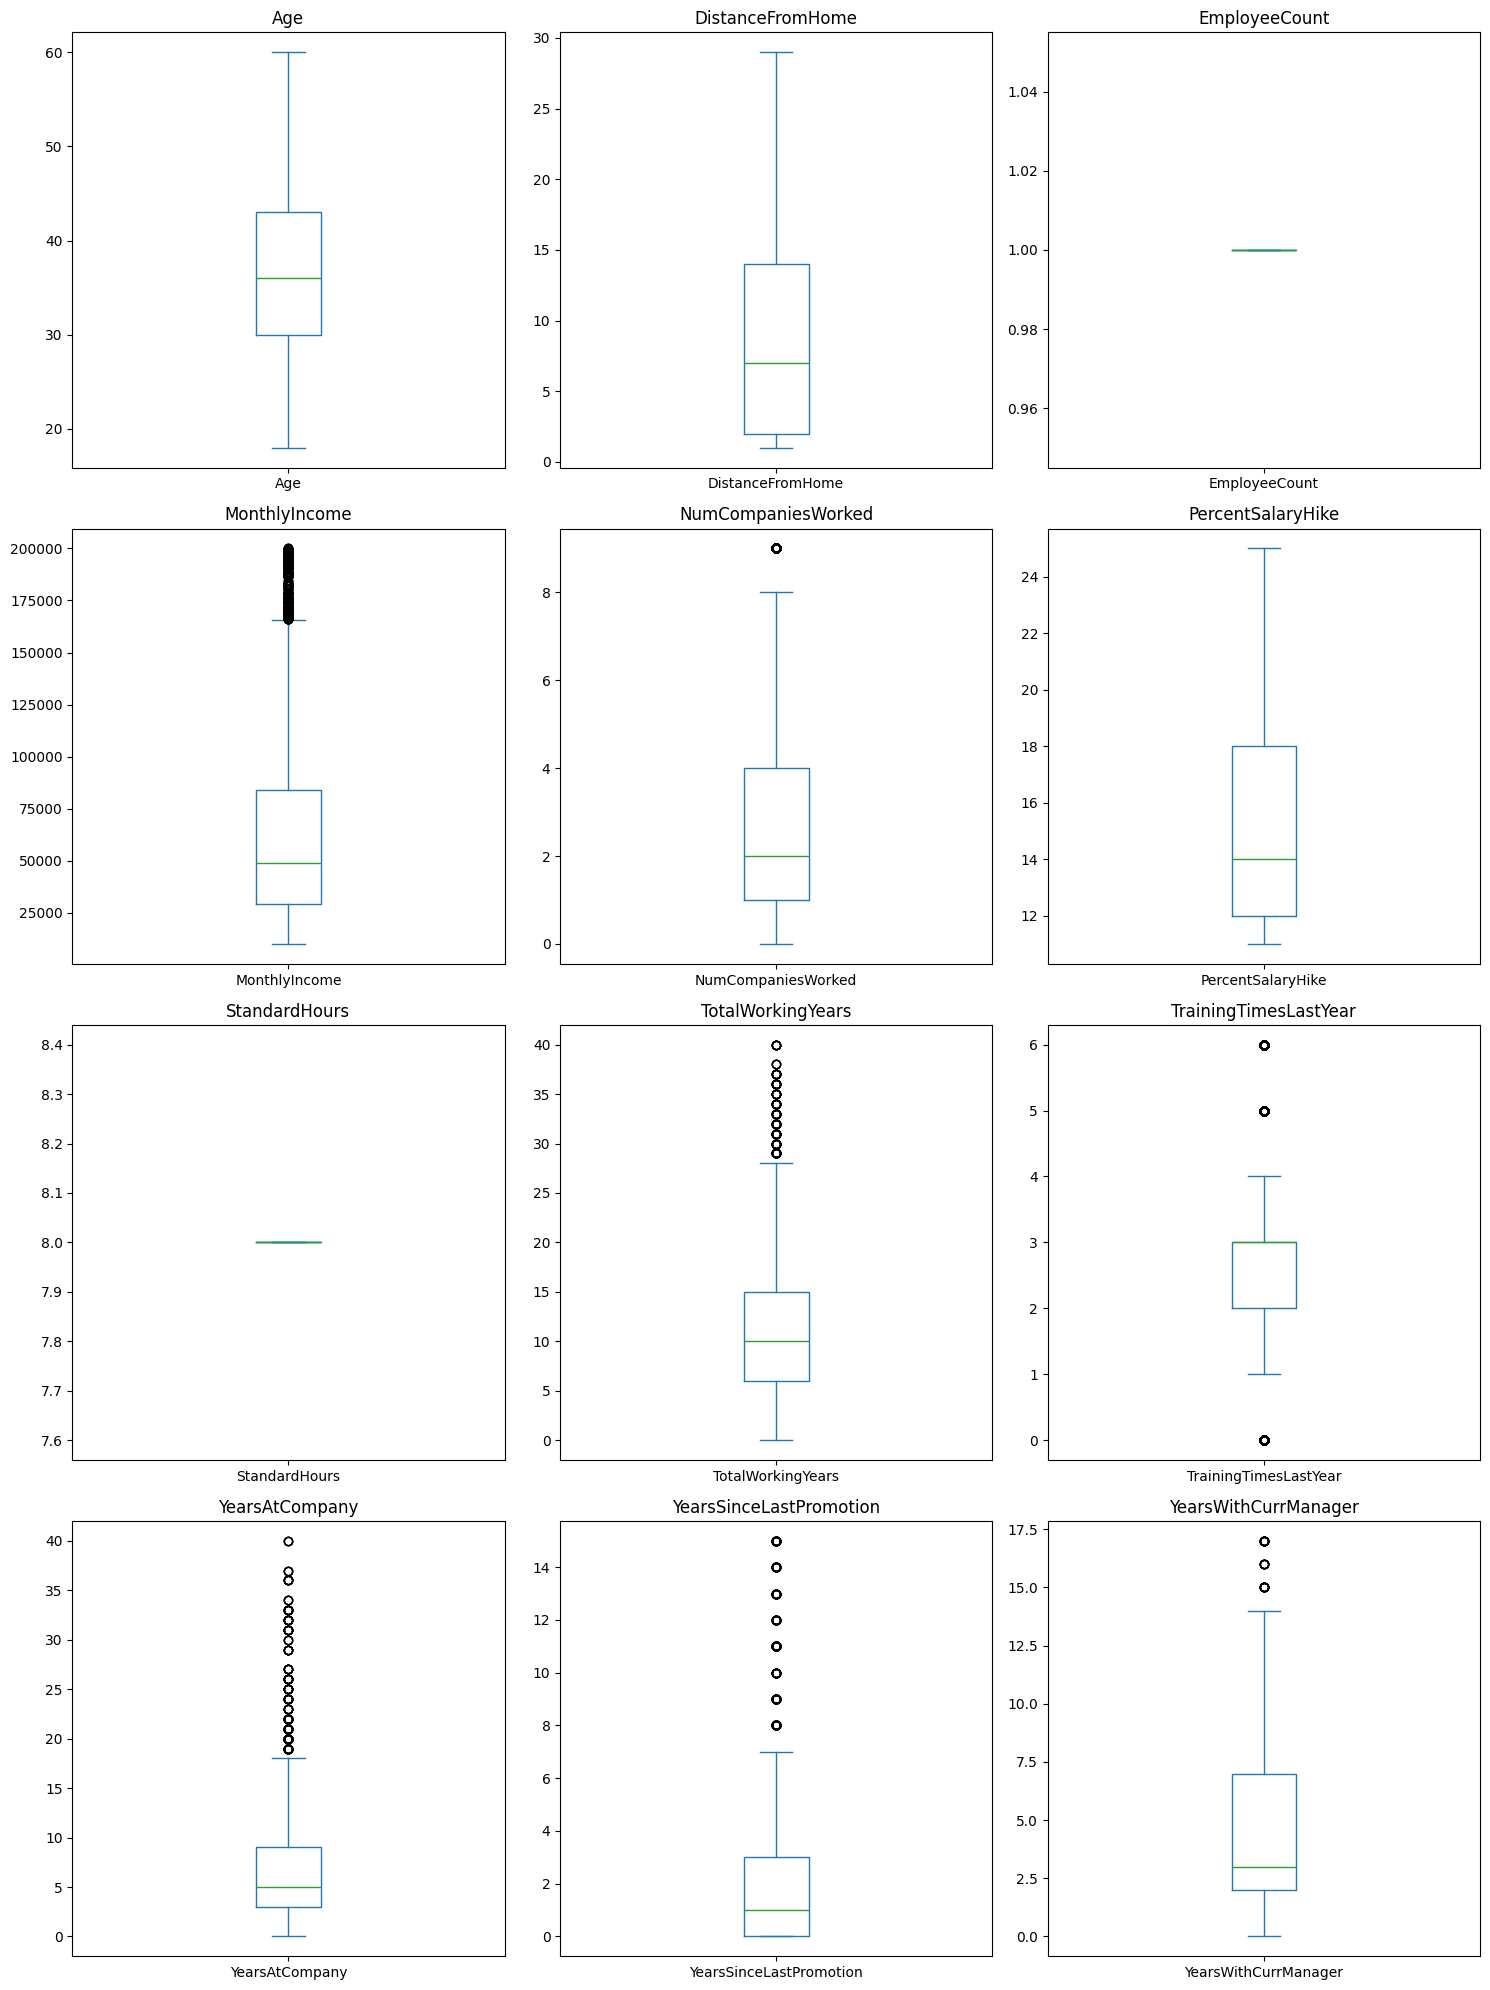

In [48]:
import matplotlib.pyplot as plt

# Diagrama de caja (Boxplot) para cada variable numérica del fichero general
fig, axes = plt.subplots(nrows=len(cols_int_general) // 4 + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_int_general):
    dataframes["general"][col].plot(kind="box", ax=axes[i], title=col)

plt.tight_layout()
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

## Análisis de boxplots – Variables numéricas

### Variables constantes

`EmployeeCount` y `StandardHours` tienen valor único para todos los empleados
(1 y 8 respectivamente), visible porque el boxplot se reduce a una línea
horizontal sin caja ni bigotes. **Deben eliminarse del análisis** al no
aportar información discriminante.

### Variables con sesgo pronunciado y outliers destacados

**`MonthlyIncome`** presenta el sesgo más acusado del conjunto: caja entre
~25.000 y ~75.000 pero con una masa densa de puntos por encima de 150.000–
200.000. Se procederà a la **transformación logarítmica** antes de incluirla
en el modelo de predicción, para aproximar su distribución a la normalidad y
reducir el peso desproporcionado de los valores extremos.

**`YearsAtCompany`**, **`TotalWorkingYears`** y **`YearsWithCurrManager`**
comparten el mismo patrón: mediana baja, cola larga hacia la derecha y
múltiples outliers. Reflejan que la mayoría de empleados tiene poca
antigüedad, con un grupo reducido de trayectorias muy largas.

**`YearsSinceLastPromotion`** tiene mediana cercana a 1 año con outliers
hasta 13–14 años, indicando casos extremos de estancamiento profesional.

### Variables con distribución aceptable

**`Age`** es la más simétrica, sin outliers y con distribución equilibrada
entre ~30 y ~43 años. **`DistanceFromHome`**, **`PercentSalaryHike`** y
**`TrainingTimesLastYear`** muestran distribuciones razonablemente compactas
con outliers aislados de escasa magnitud.

**`StockOptionLevel`** y **`NumCompaniesWorked`** son discretas con rango
reducido; la primera debería tratarse como **factor ordinal** en el modelo.

---

### Por lo que se procede a:
  
1. Eliminar `EmployeeCount` y `StandardHours`.
2. Aplicar transformación logarítmica a `MonthlyIncome`.

</div>

In [49]:
# 1. Eliminamos EmployeeCount y StandardHours ya que son constantes
#    y no aportan información al análisis.
dataframes["general"] = dataframes["general"].drop(columns=["EmployeeCount", "StandardHours"])

# 2. Aplicamos transformación logarítmica a MonthlyIncome
#    para reducir el efecto de los valores extremos y normalizar su distribución.
dataframes["general"]["MonthlyIncome_log"] = np.log(dataframes["general"]["MonthlyIncome"])

# 3 Imputación de valores

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

Tal como se ha observado en el apartado anterior el dataset *general* presenta valores perdidos en dos variables numéricas:

| Variable | Nº Missings | % Registros |
|---|---|---|
| *NumCompaniesWorked* | 19 | ~0.4% |
| *TotalWorkingYears* | 9 | ~0.2% |

Se ha optado por la imputación mediante **k vecinos más próximos (kNN)** dado que el método kNN busca, para cada registro con un valor perdido, los *k* registros más similares en base a sus características numéricas. El valor imputado es la **mediana** de esos *k* vecinos, lo que lo hace especialmente robusto frente a outliers — una ventaja relevante dado el sesgo observado en ambas variables en el análisis previo.

Se elige kNN frente a la imputación por media/mediana global porque tiene en cuenta el **perfil completo de cada empleado** (edad, nivel de trabajo, ingresos, etc.) para estimar el valor faltante, produciendo imputaciones más plausibles y contextualizadas. Se usa **k=5** (valor por defecto recomendado).

</div>

In [50]:
from sklearn.impute import KNNImputer

# Verificamos los valores perdidos antes de la imputación
print("Valores perdidos antes de la imputación:")
print(dataframes["general"][["NumCompaniesWorked", "TotalWorkingYears"]].isnull().sum())

# Seleccionamos las variables numéricas para calcular las distancias
# Se usan todas las variables numéricas para que la similitud entre
# registros sea lo más informativa posible
num_cols = dataframes["general"].select_dtypes(include=np.number).columns.tolist()

# Imputación KNN (k=5)
imputer = KNNImputer(n_neighbors=5)
dataframes["general"][num_cols] = imputer.fit_transform(dataframes["general"][num_cols])

# Verificamos que no quedan valores perdidos
print("\nValores perdidos después de la imputación:")
print(dataframes["general"][["NumCompaniesWorked", "TotalWorkingYears"]].isnull().sum())

# Estadísticos descriptivos tras la imputación
print("\nEstadísticos descriptivos tras la imputación:")
display(dataframes["general"][["NumCompaniesWorked", "TotalWorkingYears"]].describe().round(2))


Valores perdidos antes de la imputación:
NumCompaniesWorked    19
TotalWorkingYears      9
dtype: int64

Valores perdidos después de la imputación:
NumCompaniesWorked    0
TotalWorkingYears     0
dtype: int64

Estadísticos descriptivos tras la imputación:


,NumCompaniesWorked,TotalWorkingYears
count,4410.00,4410.00
mean,2.70,11.28
std,2.49,7.78
min,0.00,0.00
25%,1.00,6.00
50%,2.00,10.00
75%,4.00,15.00
max,9.00,40.00


# 4 Creación de nuevas variables

# 5 Estudio descriptivo

## 5.1 Estudio descriptivo de las variables cualitativas

## 5.2 Estudio descriptivo de las variables cuantitativas

# 6 Archivo final

# 7 Informe ejecutivo